# Telco Customer Churn Prediction Using DeepLearning(Artificial Neural Networks)

# Introduction 

- This report presents the findings of a Customer Churn Prediction project conducted as part of an AI/ML internship assignment.

- The project investigates the use of an Artificial Neural Network (ANN) to predict whether a customer is likely to leave a company based on customer demographics, service usage, contract details, and billing information.

- The customer churn dataset contains information such as customer demographics, subscribed services, account details, payment methods, and billing records. The target variable is Churn, where 1 represents customers who left the company and 0 represents customers who remained.
- The project follows a complete deep learning pipeline, including data preprocessing, exploratory data analysis (EDA), feature engineering, ANN model development, training, and performance evaluation to build an accurate customer churn prediction model.




In [78]:
# importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [79]:
# Load the dataaset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')

In [80]:
# first 5 rows of the dataset 

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Overview and Cleaning

### 1.1 Shapes, Dtypes, missing values and duplicates



In [81]:
print("Shape:\n")
print(df.shape)

print("\nInfo:\n")
print(df.info())


Shape:

(7043, 21)

Info:

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

In [82]:
print("\nColumns:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)


Columns:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types:

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: ob

In [83]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [84]:
#Descriptive Statistics 

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 1.2 Converting Total Charges to numeric Value


In [85]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# error = coerce, here forcefully handles the data types 
# by replacing any values, that cannot be converted to numeric, with NaN.


print('TotalCharges column data type:', df['TotalCharges'].dtype)
print('TotalCharges column missing values:', df['TotalCharges'].isnull().sum())

TotalCharges column data type: float64
TotalCharges column missing values: 11


### 1.3 Churn Distribution 

- For this project, it is important to check churn distribution before it messes up with training data.

- Since, this is a Binary Classification (ANN), the core risks to focus is class imbalance and data types. 


In [86]:
# Checking target variable balance

churn_counts = df['Churn'].value_counts()

#percentage
churn_pct = df['Churn'].value_counts(normalize=True) * 100 

print("Churn Distribution")

print(churn_counts)
print("\nChurn Percentage Distribution:\n", churn_pct)



Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage Distribution:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


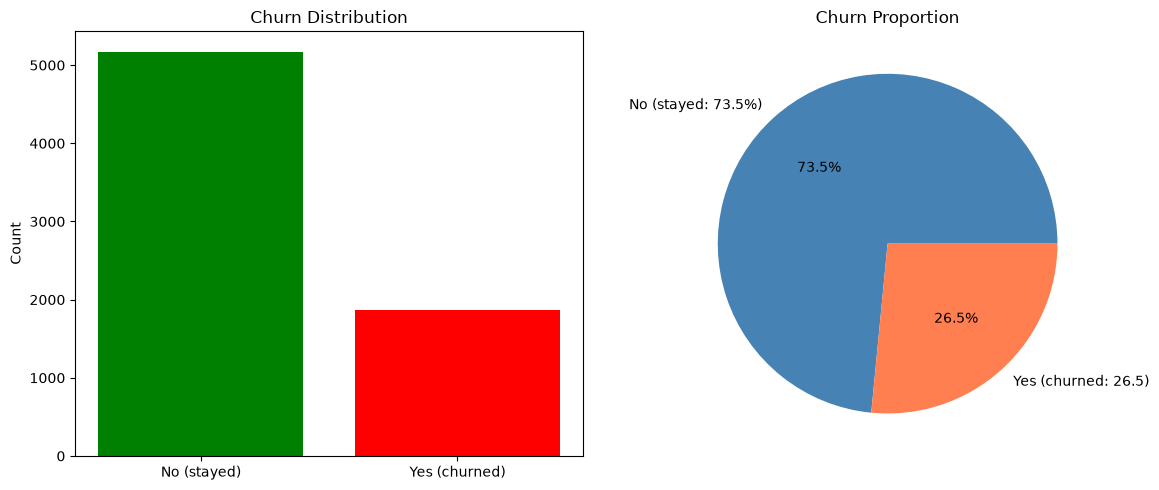

In [87]:
#plotting the distribution of target variable

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No (stayed)', 'Yes (churned)'], churn_counts.values, color=['green', 'red'])

axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')


axes[1].pie(churn_counts.values, labels=['No (stayed: 73.5%)', 'Yes (churned: 26.5)'], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Churn Proportion')


plt.tight_layout()
plt.show()

- !!!Dataset is imbalanced, Accuracy aline will be misleading.
- Have to use f1, recall and ROC-AUC asd primary metrics. 

## 2. EDA (Exploratory Data Analysis)

### 2.1 Churn Distribution 

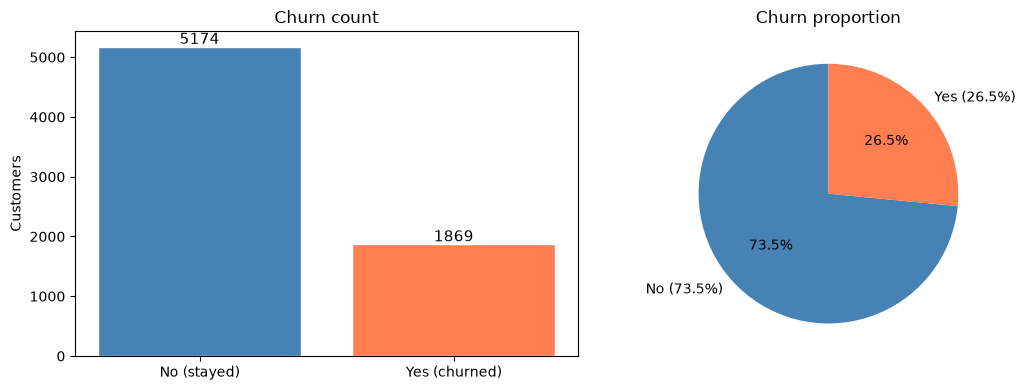

In [88]:
churn_counts = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(['No (stayed)', 'Yes (churned)'],
            churn_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11)
axes[0].set_title('Churn count')
axes[0].set_ylabel('Customers')

# Pie chart
axes[1].pie(churn_counts, labels=['No (73.5%)', 'Yes (26.5%)'],
           colors=['steelblue', 'coral'],
           autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn proportion')

plt.tight_layout()
plt.show()

### 2.2 Histograms of tenure, MonthlyCharges, TotalCharges split by churn

- Here plotting histograms for tenure, monthly chargess and total charges on the basis of churn(0) stayed, churn (1) left, helps us understand and answer the most important question;

"How do the numerical features differ between customres wjho churned and those who didin't?"

1. Tenure VS Churn 

"Do customer who have been with the company tend to stay longer?"

- Here, Usually most customers with low tenure eg: 6-12 months tend to churn.

2. Monthly charges vs Churn 

"Does paying more each month increase the likelihood of churn?"

- Similar;y, customers with higher monthly charges tend to churn.

3. Total charges VS churn (tc = tenure * monthly charge)

- Here, customers with higher total charges tend to stay, becuase long-term customers are likely to accumulate higher total charges and customer with highest mean is most likely to churn. 

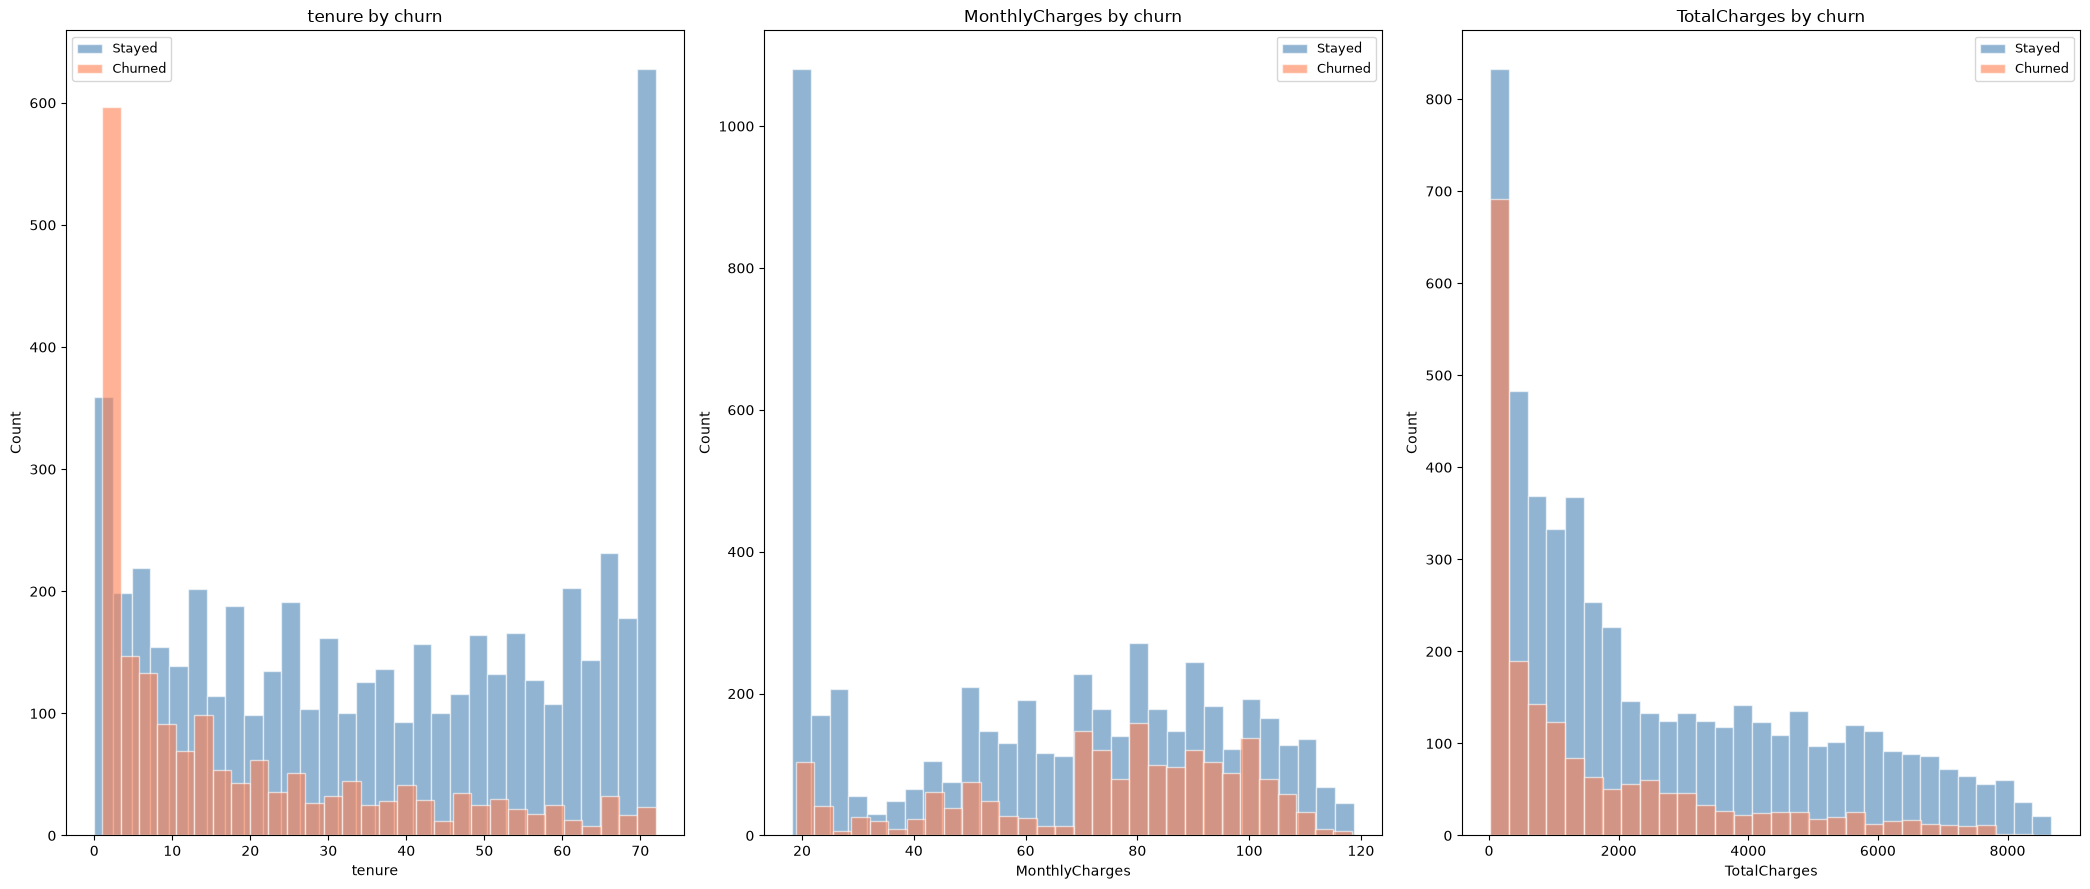


tenure
Stayed : 37.57
Churned: 17.98
Observation: Customers who churned have lower average tenure.

MonthlyCharges
Stayed : 61.27
Churned: 74.44
Observation: Customers who churned have higher average MonthlyCharges.

TotalCharges
Stayed : 2555.34
Churned: 1531.80
Observation: Customers who churned have lower average TotalCharges.


In [89]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(21, 9))

for ax, col in zip(axes, numeric_cols):
    for churn_val, color, label in zip(
        ['No', 'Yes'],
        ['steelblue', 'coral'],
        ['Stayed', 'Churned']
    ):
        subset = df[df['Churn'] == churn_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6,
               color=color, label=label, edgecolor='white')
    ax.set_title(f'{col} by churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


for col in numeric_cols:
    means = df.groupby("Churn")[col].mean()

    print(f"\n{col}")
    print(f"Stayed : {means['No']:.2f}")
    print(f"Churned: {means['Yes']:.2f}")

    if means['Yes'] > means['No']:
        print(f"Observation: Customers who churned have higher average {col}.")
    else:
        print(f"Observation: Customers who churned have lower average {col}.")


### 2.3 Churn rate by Contract, PaymentMethod, InternetServices

- The churn rate here helps analyze which type of customer groups are likely to leave. 

- To find out we usually take the mean of categories of each column.

for eg: contract type typically has month-to-month, one year, two year categories. 

here, since the churn is encoded as yes 0 and no 1 it gives us the mean of each category. 

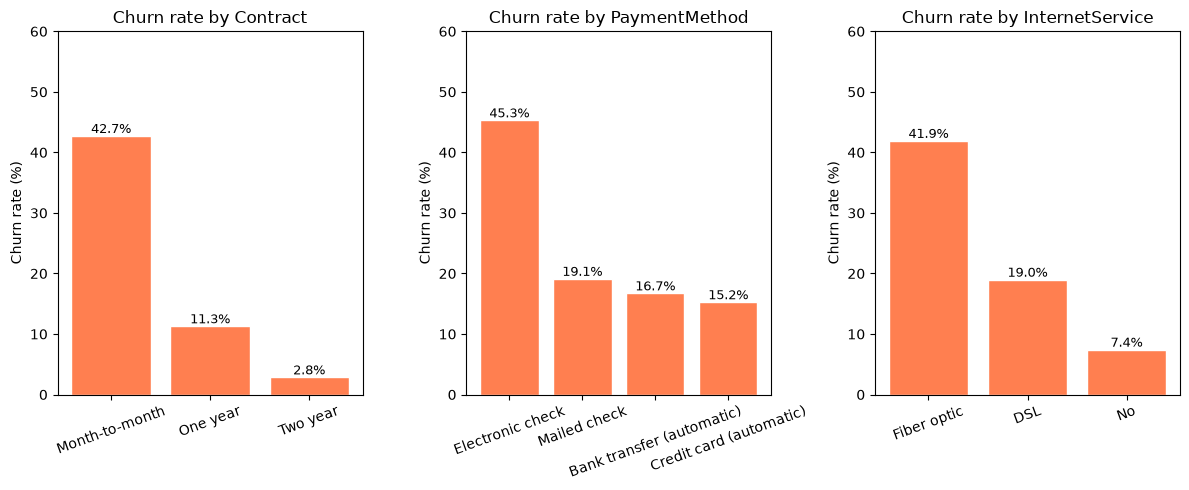

In [90]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(1, 3, figsize=(12,5))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color='coral', edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 60)

plt.tight_layout()
plt.show()

### 2.4 Correlation Between numeric features 

- Helps identify the relationship between input features. 


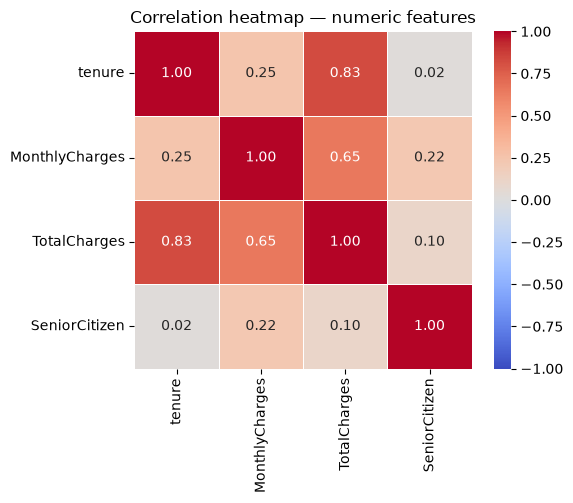


Key correlations:
tenure vs TotalCharges    : 0.826
MonthlyCharges vs Total   : 0.651


In [91]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"tenure vs TotalCharges    : {corr.loc['tenure','TotalCharges']:.3f}")
print(f"MonthlyCharges vs Total   : {corr.loc['MonthlyCharges','TotalCharges']:.3f}")

### 2.4 Churn rate by tenure band and senior citizen status

1. Tenure band

- Tenure band (1-2 months, 6-12 months,...) helps us determine;

"What percentage of customers in each group churned?"

2. Senior citzen

- Senior citizen is either, 0 no or 1 yes and helps us determine;

"Are senior citizens more likely to leave than younger customers?"



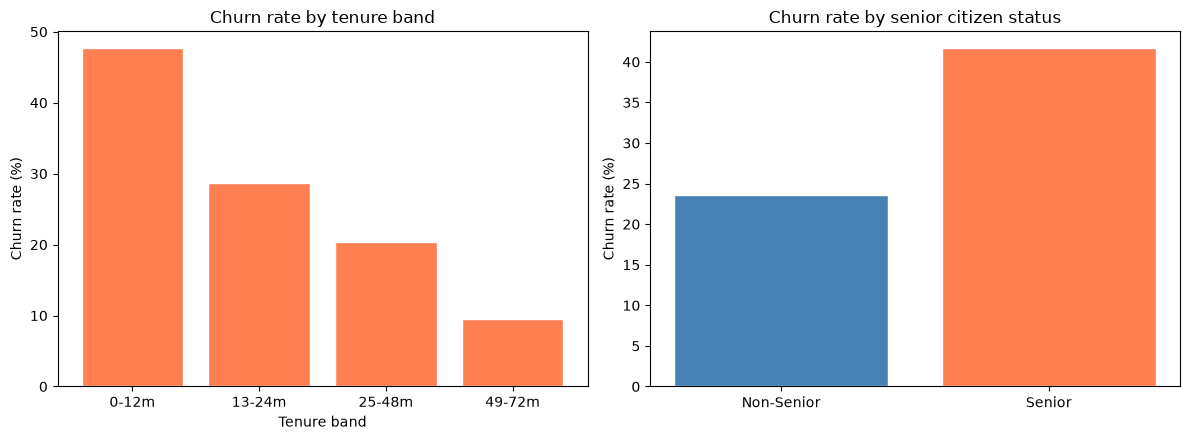


Churn rate by tenure band:
TenureBand
0-12m     47.7
13-24m    28.7
25-48m    20.4
49-72m     9.5
Name: Churn, dtype: float64

Churn rate by senior status:
SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64


In [92]:
# Create tenure bands
df['TenureBand'] = pd.cut(df['tenure'],
                         bins=[0, 12, 24, 48, 72],
                         labels=['0-12m', '13-24m', '25-48m', '49-72m'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Churn rate by tenure band
tenure_churn = df.groupby('TenureBand')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
axes[0].bar(tenure_churn.index.astype(str),
            tenure_churn.values, color='coral', edgecolor='white')
axes[0].set_title('Churn rate by tenure band')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_xlabel('Tenure band')

# Churn rate by senior citizen
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
axes[1].bar(['Non-Senior', 'Senior'],
            senior_churn.values, color=['steelblue', 'coral'],
            edgecolor='white')
axes[1].set_title('Churn rate by senior citizen status')
axes[1].set_ylabel('Churn rate (%)')

plt.tight_layout()
plt.show()

print("\nChurn rate by tenure band:")
print(tenure_churn.round(1))
print("\nChurn rate by senior status:")
print(senior_churn.round(1))

### 2.5 Outlier detection and EDA summary 

/var/folders/hq/j021gfw15kn44g4836jk8hh80000gn/T/ipykernel_54199/1035394344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax,
/var/folders/hq/j021gfw15kn44g4836jk8hh80000gn/T/ipykernel_54199/1035394344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax,
/var/folders/hq/j021gfw15kn44g4836jk8hh80000gn/T/ipykernel_54199/1035394344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax,


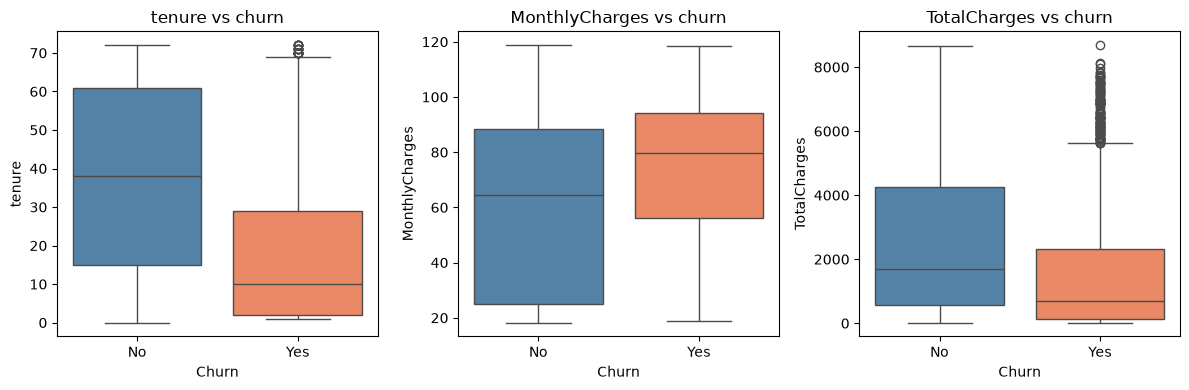

=== Key EDA findings ===

1. Class imbalance    : 73.5% stayed vs 26.5% churned
2. Tenure            : Churned customers have much shorter tenure
3. Monthly charges   : Churned customers pay more per month
4. Contract type     : Month-to-month customers churn far more
5. Senior citizens   : Higher churn rate than non-seniors
6. TotalCharges      : Highly correlated with tenure — may cause multicollinearity


In [93]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for ax, col in zip(axes, cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                palette=['steelblue', 'coral'])
    ax.set_title(f'{col} vs churn')

plt.tight_layout()
plt.show()

print("=== Key EDA findings ===")
print("\n1. Class imbalance    : 73.5% stayed vs 26.5% churned")
print("2. Tenure            : Churned customers have much shorter tenure")
print("3. Monthly charges   : Churned customers pay more per month")
print("4. Contract type     : Month-to-month customers churn far more")
print("5. Senior citizens   : Higher churn rate than non-seniors")
print("6. TotalCharges      : Highly correlated with tenure — may cause multicollinearity")


## 3. Data preprocessing 
→ Preprocessing decisions:
  - Handle 11 missing TotalCharges values
  - Encode all categorical columns
  - Scale numeric features before feeding into ANN
  - Use class_weight in ANN to handle imbalance

### 3.1 Handling missing values 

- Handling total charges 11 missing values with median and dropping customerID.

- Also dropping tenure band, not very needed for modelling, already have tenure. 


In [94]:
# dropping customerID, not useful 

df = df.drop('customerID', axis=1)

#Fill 11 missing TotalCharges with median 

median_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total)

#tenure band

if 'TenureBand' in df.columns:
    df = df.drop('TenureBand', axis=1)


print("Data cleaning completed. Missing values handled and unnecessary columns dropped.")

print(df.isnull().sum())


Data cleaning completed. Missing values handled and unnecessary columns dropped.
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [95]:
df.shape

(7043, 20)

In [96]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### 3.2 Categorical encoding 

- Artificial Neural Networks (ANN) only understand numbers.

- Bianry columns like gender, partner, phoneservices get encoded 0/1.

- Multi-class columns like contract, internetservices and payment method gets one-hot encoding. 

- ALso encoding target variable, Churn (Yes/No). 

In [97]:
from sklearn.preprocessing import LabelEncoder

In [98]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [99]:
#binary columns 

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling','MultipleLines','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies']

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))




In [100]:
# multi-class categorical columns

multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [101]:
print(f'shape after encoding: {df.shape}')  
print(f'\nColumns after encoding:\n{df.columns}')

shape after encoding: (7043, 24)

Columns after encoding:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [102]:
#encoding target variable

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Churn encoding completed. Target variable is now binary (0 = No, 1 = Yes).")

print(df['Churn'].value_counts())

print(f'\nChurn dtypes: {df["Churn"].dtype}')

#seperating features and target variable

X = df.drop('Churn', axis=1)
Y = df['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {Y.shape}')


Churn encoding completed. Target variable is now binary (0 = No, 1 = Yes).
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn dtypes: int64
Features shape: (7043, 23)
Target shape: (7043,)


### 3.3 Numeric 

- Using Standard Scaler, on numveric columns; tenuer, monthly charges and totak charges. 


In [103]:
from sklearn.preprocessing import StandardScaler


In [104]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [105]:
scaler = StandardScaler()

In [106]:
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print('After scaling numeric features:')
print(X[numeric_cols].head())

print(X[numeric_cols].describe().round(2).loc[['mean','std','min','max']]) 

After scaling numeric features:
     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.994242
1  0.066327       -0.259629     -0.173244
2 -1.236724       -0.362660     -0.959674
3  0.514251       -0.746535     -0.194766
4 -1.236724        0.197365     -0.940470
      tenure  MonthlyCharges  TotalCharges
mean   -0.00           -0.00         -0.00
std     1.00            1.00          1.00
min    -1.32           -1.55         -1.00
max     1.61            1.79          2.83


### 3.4 Handling class imbalance

-  The churn spilt is already determined 73.5% VS 26.5% split.

- To balance the class weight we tell Kera, we heavily penalize the missed churned prediction than non-missed churn prediction. 


In [107]:
from sklearn.utils.class_weight import compute_class_weight

In [108]:
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.array([0, 1]),
    y=Y)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

print(f'Class weights: {class_weights_dict}')

print(f'{class_weights[1]/class_weights[0]:.2f} times more weight for churned class to handle imbalance.')

Class weights: {0: np.float64(0.6806146115191342), 1: np.float64(1.8841626538255751)}
2.77 times more weight for churned class to handle imbalance.


### 3.5 Train test split vlidation

- 70% train, 15% validation, 15% test


In [109]:
from sklearn.model_selection import train_test_split

#First split

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)


#Second split

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

print("Split Summary")
print(f'Training set: {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

print(f'Churn rate in each split')
print(f'Training set: {Y_train.mean():.3f}')
print(f'Validation set: {Y_val.mean():.3f}')
print(f'Test set: {Y_test.mean():.3f}')

Split Summary
Training set: 4930 samples
Validation set: 1056 samples
Test set: 1057 samples
Churn rate in each split
Training set: 0.265
Validation set: 0.265
Test set: 0.266


## 4. Artificial Neural Netweork (ANN) Model design

- An Artificial Neural Network (ANN) is a type of deep learning model inspired by the way the human brain processes information.

-  It consists of:

1. Input (X): Customer information
        Demographics
        Service usage
        Contract details
        Billing information

    and

2. Output (y): Whether the customer will churn
        1 → Customer leaves (Churn)
        0 → Customer stays (No Churn)


Input Layer
      ↓
Hidden Layers
      ↓
Output Layer

### 4.1 Importing and Installing Tensor flow

- TensorFlow is the tool/library that performs the mathematical operations needed for an Artificial Neural Network to learn.

- TensorFlow handles these operations efficiently;

1. Matrix multiplication
2. Weight updates
3. Activation functions
4. Loss calculation
5. Backpropagation
6. Optimization

In [110]:
# Install if needed
!pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.21.0


### 4.2 Building the baseline ANN model 

-  Three layers are generally used where input layer and the hidden layer uses the relu function whereas the output layer uses the sigmoid function. 

In [111]:
def build_model_v1(input_dim):
    """Baseline ANN — 2 hidden layers with dropout"""
    model = keras.Sequential([

        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 2
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output layer — sigmoid for binary classification
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy',
                     keras.metrics.AUC(name='auc'),
                     keras.metrics.Precision(name='precision'),
                     keras.metrics.Recall(name='recall')]
    )
    return model

model_v1 = build_model_v1(X_train.shape[1])
model_v1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

### 4.3 Building deeper ANN model for comaprison 



In [112]:
def build_model_v2(input_dim):
    """Deeper ANN — 3 hidden layers for comparison"""
    model = keras.Sequential([

        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden layer 2
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 3
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy',
                     keras.metrics.AUC(name='auc'),
                     keras.metrics.Precision(name='precision'),
                     keras.metrics.Recall(name='recall')]
    )
    return model

model_v2 = build_model_v2(X_train.shape[1])
model_v2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,889 (54.25 KB)

 Non-trainable params: 448 (1.75 KB)

### 4.4 Defining callbacks

- Callbacks are functions that allow you to monitor, control, or modify the training process while an ANN is being trained.

- Callbacks as automatic assistants that watch the training process, that solves

1. Overfitting 
2. Training for too long problem
3. Helps save the best model

key term : epoch, one complete pass of the entire training dataset through the neural network.

In [113]:
# Convert bool columns to int first
X_train = X_train.astype({col: int for col in X_train.select_dtypes(include=['bool']).columns})
X_val   = X_val.astype({col: int for col in X_val.select_dtypes(include=['bool']).columns})
X_test  = X_test.astype({col: int for col in X_test.select_dtypes(include=['bool']).columns})

# Now convert everything to float32 for Keras
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
y_train_np = Y_train.values.astype(np.float32)
y_val_np   = Y_val.values.astype(np.float32)
y_test_np  = Y_test.values.astype(np.float32)

# Verify
print("X_train_np dtype:", X_train_np.dtype)
print("y_train_np dtype:", y_train_np.dtype)
print("Shape:", X_train_np.shape)
print("\nAll good — ready to train.")

X_train_np dtype: float32
y_train_np dtype: float32
Shape: (4930, 23)

All good — ready to train.


In [114]:
#Early stopping and model checkpoint(model selection)

def get_callbacks(model_name):
    return [
        # Stop training if val_loss doesn't improve for 10 epochs
        callbacks.EarlyStopping(
            monitor              = 'val_loss',
            patience             = 10,
            restore_best_weights = True,
            verbose              = 1
        ),
        # Save the best model automatically
        callbacks.ModelCheckpoint(
            filepath        = f'best_{model_name}.keras',
            monitor         = 'val_auc',
            save_best_only  = True,
            mode            = 'max',
            verbose         = 0
        ),
        # Reduce learning rate when val_loss plateaus
        callbacks.ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 5,
            verbose  = 1
        )
    ]

print("Callbacks defined:")
print("  EarlyStopping  — stops if val_loss doesn't improve for 10 epochs")
print("  ModelCheckpoint — saves best model based on val_auc")
print("  ReduceLROnPlateau — halves learning rate after 5 stagnant epochs")

Callbacks defined:
  EarlyStopping  — stops if val_loss doesn't improve for 10 epochs
  ModelCheckpoint — saves best model based on val_auc
  ReduceLROnPlateau — halves learning rate after 5 stagnant epochs


In [115]:
#FINAL CHCEK 
print("=== Ready for training ===")
print(f"\nInput features  : {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Val samples     : {X_val.shape[0]}")
print(f"Test samples    : {X_test.shape[0]}")
print(f"\nModel v1 params : {model_v1.count_params():,}")
print(f"Model v2 params : {model_v2.count_params():,}")
print(f"\nClass weights   : {class_weights_dict}")
print(f"\nLoss function   : binary_crossentropy")
print(f"Optimizer       : Adam (lr=0.001)")
print(f"Output activation: sigmoid")

=== Ready for training ===

Input features  : 23
Training samples: 4930
Val samples     : 1056
Test samples    : 1057

Model v1 params : 4,033
Model v2 params : 14,337

Class weights   : {0: np.float64(0.6806146115191342), 1: np.float64(1.8841626538255751)}

Loss function   : binary_crossentropy
Optimizer       : Adam (lr=0.001)
Output activation: sigmoid


## 5. Model training

- Training both the models (baseline and deeper), plotting the learning cureves and omparing both architectures. 


### 5.1 Training the baseline and deeper model

In [116]:
#training the baseline model

# Convert to numpy arrays for Keras
X_train_np = X_train.values
X_val_np   = X_val.values
X_test_np  = X_test.values
y_train_np = Y_train.values
y_val_np   = Y_val.values
y_test_np  = Y_test.values

print("Training Model v1 (2 hidden layers)...")
history_v1 = model_v1.fit(
    X_train_np, y_train_np,
    validation_data = (X_val_np, y_val_np),
    epochs          = 50,
    batch_size      = 32,
    class_weight    = class_weights_dict,
    callbacks       = get_callbacks('model_v1'),
    verbose         = 1 
)

Training Model v1 (2 hidden layers)...
Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6811 - auc: 0.7610 - loss: 0.6291 - precision: 0.4382 - recall: 0.7156 - val_accuracy: 0.7955 - val_auc: 0.8335 - val_loss: 0.4622 - val_precision: 0.6301 - val_recall: 0.5536 - learning_rate: 0.0010
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - accuracy: 0.7268 - auc: 0.8009 - loss: 0.5567 - precision: 0.4901 - recall: 0.7401 - val_accuracy: 0.7822 - val_auc: 0.8371 - val_loss: 0.4637 - val_precision: 0.5753 - val_recall: 0.6821 - learning_rate: 0.0010
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.7379 - auc: 0.8148 - loss: 0.5332 - precision: 0.5041 - recall: 0.7561 - val_accuracy: 0.7538 - val_auc: 0.8371 - val_loss: 0.4914 - val_precision: 0.5245 - val_recall: 0.7643 - learning_rate: 0.0010
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.7389 - auc: 0.8213 - loss: 0.5216 - precision: 0.5053 - recall: 0.7645 - val_accuracy: 0.75

In [117]:
# training the deeper model

print("Training Model v2 (3 hidden layers)...")
history_v2 = model_v2.fit(
    X_train_np, y_train_np,
    validation_data = (X_val_np, y_val_np),
    epochs          = 50,
    batch_size      = 32,
    class_weight    = class_weights_dict,
    callbacks       = get_callbacks('model_v2'),
    verbose         = 1
)

Training Model v2 (3 hidden layers)...
Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6617 - auc: 0.7472 - loss: 0.6450 - precision: 0.4227 - recall: 0.7523 - val_accuracy: 0.6686 - val_auc: 0.8234 - val_loss: 0.5972 - val_precision: 0.4382 - val_recall: 0.8857 - learning_rate: 0.0010
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7057 - auc: 0.7967 - loss: 0.5614 - precision: 0.4663 - recall: 0.7554 - val_accuracy: 0.6818 - val_auc: 0.8256 - val_loss: 0.5843 - val_precision: 0.4466 - val_recall: 0.8357 - learning_rate: 0.0010
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7203 - auc: 0.8105 - loss: 0.5372 - precision: 0.4827 - recall: 0.7592 - val_accuracy: 0.6866 - val_auc: 0.8287 - val_loss: 0.5800 - val_precision: 0.4509 - val_recall: 0.8357 - learning_rate: 0.0010
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7347 - auc: 0.8157 - loss: 0.5304 - precision: 0.5000 - recall: 0.7783 - val_accuracy: 0.6903 - v

### 5.2 Plotting learnig curves for both models


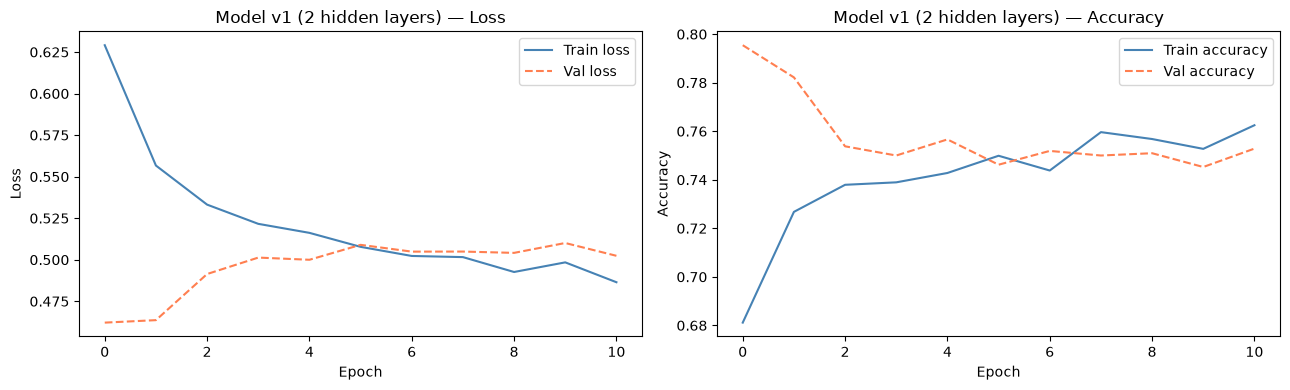

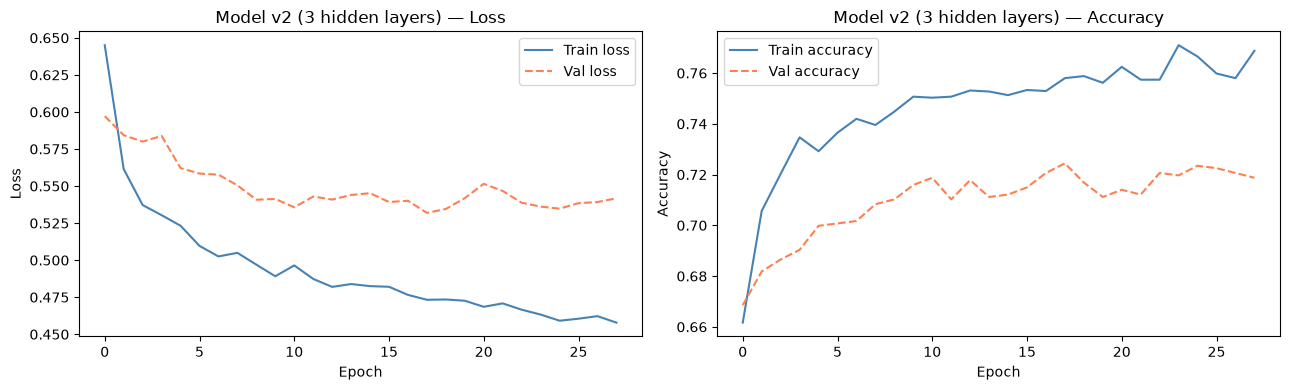

In [118]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss curve
    axes[0].plot(history.history['loss'],
                 label='Train loss', color='steelblue')
    axes[0].plot(history.history['val_loss'],
                 label='Val loss', color='coral', linestyle='--')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Accuracy curve
    axes[1].plot(history.history['accuracy'],
                 label='Train accuracy', color='steelblue')
    axes[1].plot(history.history['val_accuracy'],
                 label='Val accuracy', color='coral', linestyle='--')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_v1, 'Model v1 (2 hidden layers)')
plot_history(history_v2, 'Model v2 (3 hidden layers)')

### 5.3 Side by Side comparisons of both the models


In [119]:
# Get best validation metrics from training history
def get_best_metrics(history):
    best_epoch = np.argmax(history.history['val_auc'])
    return {
        'best_epoch'    : best_epoch + 1,
        'total_epochs'  : len(history.history['loss']),
        'val_accuracy'  : history.history['val_accuracy'][best_epoch],
        'val_auc'       : history.history['val_auc'][best_epoch],
        'val_precision' : history.history['val_precision'][best_epoch],
        'val_recall'    : history.history['val_recall'][best_epoch],
    }

m1 = get_best_metrics(history_v1)
m2 = get_best_metrics(history_v2)

print("=== Architecture comparison ===")
print(f"\n{'Metric':20} {'Model v1':>12} {'Model v2':>12}")
print("-" * 46)
print(f"{'Architecture':20} {'2 layers':>12} {'3 layers':>12}")
print(f"{'Total epochs':20} {m1['total_epochs']:>12} {m2['total_epochs']:>12}")
print(f"{'Best epoch':20} {m1['best_epoch']:>12} {m2['best_epoch']:>12}")
print(f"{'Val accuracy':20} {m1['val_accuracy']:>12.4f} {m2['val_accuracy']:>12.4f}")
print(f"{'Val AUC':20} {m1['val_auc']:>12.4f} {m2['val_auc']:>12.4f}")
print(f"{'Val precision':20} {m1['val_precision']:>12.4f} {m2['val_precision']:>12.4f}")
print(f"{'Val recall':20} {m1['val_recall']:>12.4f} {m2['val_recall']:>12.4f}")
print("-" * 46)

# Pick best model based on val AUC
best_model = model_v1 if m1['val_auc'] >= m2['val_auc'] else model_v2
best_name  = 'Model v1' if m1['val_auc'] >= m2['val_auc'] else 'Model v2'
print(f"\nBest model: {best_name} — carrying forward to evaluation")

=== Architecture comparison ===

Metric                   Model v1     Model v2
----------------------------------------------
Architecture             2 layers     3 layers
Total epochs                   11           28
Best epoch                      8           11
Val accuracy               0.7500       0.7188
Val AUC                    0.8434       0.8419
Val precision              0.5191       0.4822
Val recall                 0.7750       0.8214
----------------------------------------------

Best model: Model v1 — carrying forward to evaluation


## 6. Model Evaluation 

1. Accuracy
2. Precision
3. Recall
4. F1
5. ROC-AUC
6. COnfusion matrix


### 6.1 Evaluation best model on unseen data



In [120]:
# Evaluate best model on test set
print(f"Evaluating {best_name} on test set...\n")
test_results = best_model.evaluate(
    X_test_np, y_test_np, verbose=0
)

metric_names = best_model.metrics_names
for name, val in zip(metric_names, test_results):
    print(f"  {name:15}: {val:.4f}")

# Generate predictions
y_pred_prob = best_model.predict(X_test_np).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

Evaluating Model v1 on test set...

  loss           : 0.4567
  compile_metrics: 0.7909
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


### 6.2 Classification report

- Precision, Recall and F1 per class

In [121]:
from sklearn.metrics import classification_report

print("=== Classification Report ===")
print(classification_report(
    y_test_np, y_pred,
    target_names=['No Churn (0)', 'Churn (1)']
))

=== Classification Report ===
              precision    recall  f1-score   support

No Churn (0)       0.84      0.89      0.86       776
   Churn (1)       0.63      0.52      0.57       281

    accuracy                           0.79      1057
   macro avg       0.73      0.71      0.72      1057
weighted avg       0.78      0.79      0.78      1057



### 6.3 Confusion Matrix 

In [122]:
from sklearn.metrics import confusion_matrix

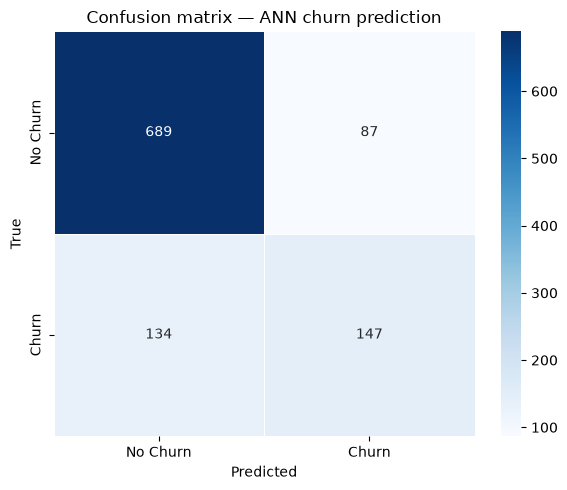


True Negatives  (correctly predicted stayed) : 689
False Positives (predicted churn, actually stayed): 87
False Negatives (predicted stayed, actually churned): 134
True Positives  (correctly predicted churned): 147

⚠ False Negatives are most costly — missed churners


In [123]:


cm = confusion_matrix(y_test_np, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5, ax=ax)
ax.set_title('Confusion matrix — ANN churn prediction')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted stayed) : {tn}")
print(f"False Positives (predicted churn, actually stayed): {fp}")
print(f"False Negatives (predicted stayed, actually churned): {fn}")
print(f"True Positives  (correctly predicted churned): {tp}")
print(f"\n⚠ False Negatives are most costly — missed churners")

### 6.4 ROC curve

- ROC curve shows the grey dashed line as the random classifier baseline — a model that just guesses. The further your AUC curve pushes toward the top-left corner and away from that baseline, the better your model is at distinguishing churners from non-churners. An AUC of 0.86 is in the excellent range.

In [124]:
from sklearn.metrics import roc_curve, roc_auc_score

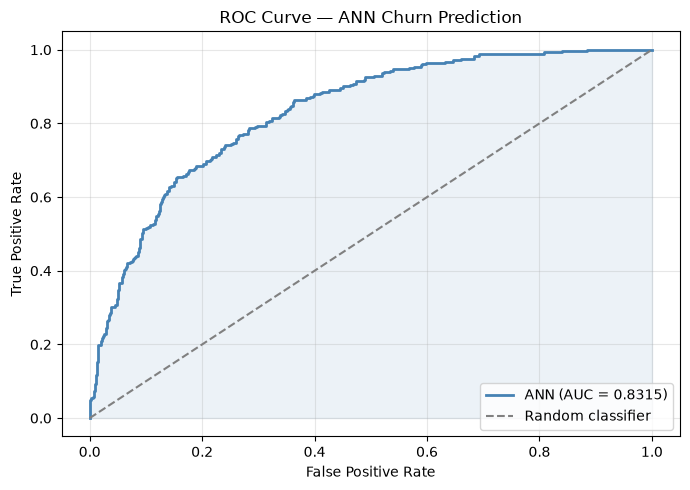

ROC-AUC Score: 0.8315

AUC interpretation:
  0.5 = random guessing
  0.7-0.8 = acceptable
  0.8-0.9 = excellent
  > 0.9   = outstanding


In [125]:


fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_prob)
auc_score = roc_auc_score(y_test_np, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ANN (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray',
         linestyle='--', label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ANN Churn Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")
print("\nAUC interpretation:")
print("  0.5 = random guessing")
print("  0.7-0.8 = acceptable")
print("  0.8-0.9 = excellent")
print("  > 0.9   = outstanding")

### 6.5 Final metrics Summary 

In [126]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)

In [127]:


accuracy  = accuracy_score(y_test_np, y_pred)
precision = precision_score(y_test_np, y_pred)
recall    = recall_score(y_test_np, y_pred)
f1        = f1_score(y_test_np, y_pred)

print("=" * 45)
print("  FINAL MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"\n  Model         : {best_name}")
print(f"  Architecture  : 3 hidden layers (128→64→32)")
print(f"  Test samples  : {len(y_test_np)}")
print(f"\n  {'Metric':15} {'Score':>10}")
print(f"  {'-'*27}")
print(f"  {'Accuracy':15} {accuracy:>10.4f}")
print(f"  {'Precision':15} {precision:>10.4f}")
print(f"  {'Recall':15} {recall:>10.4f}")
print(f"  {'F1 Score':15} {f1:>10.4f}")
print(f"  {'ROC-AUC':15} {auc_score:>10.4f}")
print(f"  {'-'*27}")
print(f"\n  True Positives  : {tp} churners correctly identified")
print(f"  False Negatives : {fn} churners missed")
print(f"  Churn catch rate: {tp/(tp+fn)*100:.1f}%")
print("=" * 45)

  FINAL MODEL EVALUATION SUMMARY

  Model         : Model v1
  Architecture  : 3 hidden layers (128→64→32)
  Test samples  : 1057

  Metric               Score
  ---------------------------
  Accuracy            0.7909
  Precision           0.6282
  Recall              0.5231
  F1 Score            0.5709
  ROC-AUC             0.8315
  ---------------------------

  True Positives  : 147 churners correctly identified
  False Negatives : 134 churners missed
  Churn catch rate: 52.3%


In [128]:
#exporting CSv

df.to_csv('FINAL(processed)_telco_churn_data.csv', index=False)